<div style="text-align:center;">
  <h1 size=10>
    <b>MLOps PROJECT</b><br>
    <b></b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group ??**
- Bárbara Franco (20250388)
- Inês Caetano (20221950)
- João Bernardo (20221889)
- Maria Carvalho (20221953)
- Maria Miguel Fonseca (20250380)

**GitHub repository: https://github.com/barbara-sousa-franco/MLOps_Project**

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Set Up & Import Libraries](#1)
- [2. Load Data](#2)
- [3. Pre-Split Cleaning](#3)
    - [3.1. Remove duplicates](#3_1)
    - [3.2 Remove columns](#3_2)
    - [3.3 Remove rows outside of Portugal](#3_3)
    - [3.4 Convert impossible and improbable value to NA](#3_4)
    - [3.5 Remove rows without Price](#3_5)
    - [3.6 Consolidate EnergyCertificate](#3_6)
    - [3.7 Non-Residential types consistency](#3_7)
    - [3.8 Typecasting](#3_8)
    - [3.9 Ordinal Enconding for EnergyCertificate](#3_9)
    - [3.10 Log-transform skewed numeric features](#3_10)
    - [3.11 Save to data/02_intermediate](#3_11)
- [4. Train/Test Split](#4)
    - [4.1 Save to data/03_primary](#4_1)
- [5. Post-Split Cleaning](#5)
    - [5.1 Custom percentile capper](#5_1)
    - [5.2 Imputer](#5_2)
    - [5.3 Percentile Capping](#5_3)
    - [5.4 Target Encoding](#5_4)
    - [5.5 Scaling](#5_5)
- [6. Visualizations](#6)



# <font color='#2f94d7' size=6>**1. Set Up & Import Libraries**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder, StandardScaler
from scipy.stats import chi2_contingency

In [50]:
# global variables
SEED = 23
TEST_SIZE = 0.2

NON_RESIDENTIAL_TYPES = [
    'Land', 'Garage', 'Warehouse', 'Storage', 'Industrial', 'Commercial'
]
 
ENERGY_ORDER = ['A+', 'A', 'B', 'B-', 'C', 'D', 'E', 'F', 'G', 'No Rating']
 
PERCENTILE_THRESHOLDS = {
    'NumberOfBedrooms':  0.995,
    'NumberOfBathrooms': 0.995,
    'NumberOfWC':        0.995,
    'TotalRooms':        0.990,
}

# <font color='#2f94d7' size=6>**2. Load Data**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [51]:
df = pd.read_csv('../data/01_raw/portugal_listings.csv')
print(f"Raw data shape: {df.shape}")

Raw data shape: (135536, 25)


C:\Users\35191\AppData\Local\Temp\ipykernel_15624\4092014747.py:1: DtypeWarning: Columns (9,10,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/01_raw/portugal_listings.csv')


# <font color='#2f94d7' size=6>**3. Pre-Split cleaning**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6>**3.1 Remove duplicates**</font> <a class="anchor" id="3_1"></a>

[Back to TOC](#toc)

In [52]:
duplicated_rows = df[df.duplicated()]
print(f"Number of duplicated rows: {len(duplicated_rows)}")
print(f"Percentage of duplicated rows: {len(duplicated_rows) / len(df) * 100:.2f}%")
df.drop_duplicates(keep=False,inplace=True)
print(f"Number of duplicated rows after dropping: {len(df[df.duplicated()])}")

Number of duplicated rows: 8913
Percentage of duplicated rows: 6.58%
Number of duplicated rows after dropping: 0


# <font color='#2f94d7' size=6>**3.2 Remove columns**</font> <a class="anchor" id="3_2"></a>

[Back to TOC](#toc)

In [53]:
cols_to_drop = [
    'PublishDate',           # 78% nulls, 0.3% parseable
    'Floor',                 # 79% nulls
    'ConservationStatus',    # 86% nulls
    'EnergyEfficiencyLevel', # duplicate of EnergyCertificate
    'City',                  # cardinality 275, use District instead
    'Town',                  # cardinality 2263, use District instead
]
df = df.drop(columns=cols_to_drop)
print(f"Columns after drop: {df.shape[1]}")

Columns after drop: 19


# <font color='#2f94d7' size=6>**3.3 Remove rows outside of Portugal**</font> <a class="anchor" id="3_3"></a>

[Back to TOC](#toc)

As the goal is to model house prices in Portugal, records outside of Portugal are not relevant. Thus, they will be droped

In [54]:
n_before = len(df)
df = df[df['District'] != 'Z - Fora de Portugal']
print(f"Rows removed (outside Portugal): {n_before - len(df)}")

Rows removed (outside Portugal): 22


# <font color='#2f94d7' size=6>**3.4 Convert impossible and improbable values to NA**</font> <a class="anchor" id="3_4"></a>

[Back to TOC](#toc)

In [55]:
# Negative or zero values for certain features are not plausible in the context of real estate 
# listings. For example, a property cannot have a negative price or a negative area.
#  Similarly, a property cannot have zero bedrooms if it is listed as a residential property.
#  Therefore, we will identify and handle these implausible values by replacing them with NaN
#  (Not a Number) to indicate that they are missing or invalid. The date also has to be within 
# a reasonable range, as properties cannot be built in the far past or future.

impossible = {
    'Price':            df['Price'] <= 0,
    'GrossArea':        df['GrossArea'] < 0,
    'TotalArea':        df['TotalArea'] < 0,
    'LivingArea':       df['LivingArea'] < 0,
    'BuiltArea':        df['BuiltArea'] < 0,
    'LotSize':          df['LotSize'] < 0,
    'NumberOfWC':       df['NumberOfWC'] < 0,
    'NumberOfBathrooms':df['NumberOfBathrooms'] < 0,
    'NumberOfBedrooms': df['NumberOfBedrooms'] < 0,
    'TotalRooms':       df['TotalRooms'] < 0,
    'Parking':          df['Parking'] < 0,
    'ConstructionYear': (df['ConstructionYear'] > 2026) | (df['ConstructionYear'] < 1800),
}
for col, mask in impossible.items():
    df.loc[mask, col] = np.nan

In [56]:
# In addition to impossible values, there are also implausible values that, while not strictly 
# impossible, are highly unlikely to be accurate. For example, a property listed with a price of
#  1 euro or a property with more than 20 bedrooms is likely to be an error in the data.
#  We will also handle these implausible values by replacing them with NaN.

implausible = {
    'Price':             df['Price'] == 1,
    'NumberOfBedrooms':  df['NumberOfBedrooms'] > 20,
    'NumberOfBathrooms': df['NumberOfBathrooms'] > 20,
    'NumberOfWC':        df['NumberOfWC'] > 20,
    'TotalRooms':        df['TotalRooms'] > 50,
}
for col, mask in implausible.items():
    df.loc[mask, col] = np.nan

# <font color='#2f94d7' size=6>**3.5 Remove rows without Price**</font> <a class="anchor" id="3_5"></a>

[Back to TOC](#toc)

Records without the target are dropped.

In [57]:
n_before = len(df)
df = df.dropna(subset=['Price'])
print(f"Rows removed (missing Price): {n_before - len(df)}")

Rows removed (missing Price): 268


# <font color='#2f94d7' size=6>**3.6 Consolidate EnergyCertificate**</font> <a class="anchor" id="3_6"></a>

[Back to TOC](#toc)

In [58]:
# The EnergyCertificate column contains various values that indicate the lack of energy efficiency rating of the property.
# We will standardize these values by replacing them with a single category 'No Rating' to simplify the analysis and modeling process. 
# Additionally, we will fill any remaining missing values in this column with 'No Rating' to ensure that all properties have a 
# defined energy certificate status.
no_rating_values = ['NC', 'Not available', 'No Certificate']
df['EnergyCertificate'] = df['EnergyCertificate'].replace(no_rating_values, 'No Rating')
df['EnergyCertificate'] = df['EnergyCertificate'].fillna('No Rating')

# <font color='#2f94d7' size=6>**3.7 Non-Residencial types consistency**</font> <a class="anchor" id="3_7"></a>

[Back to TOC](#toc)

In [59]:
# Land: zeros in everything including BuiltArea
land_mask = df['Type'] == 'Land'
land_zero_cols = [
    'NumberOfBedrooms', 'NumberOfBathrooms', 'NumberOfWC',
    'TotalRooms', 'LivingArea', 'BuiltArea'
]
for col in land_zero_cols:
    df.loc[land_mask, col] = df.loc[land_mask, col].fillna(0)

# Commercials/Storage: zeros in living/rooms but keeps BuiltArea
commercial_types = [
    'Garage', 'Storage', 'Warehouse', 'Industrial',
    'Store', 'Office', 'Other - Commercial'
]
commercial_mask = df['Type'].isin(commercial_types)
commercial_zero_cols = [
    'NumberOfBedrooms', 'NumberOfBathrooms', 'NumberOfWC',
    'TotalRooms', 'LivingArea'
]
for col in commercial_zero_cols:
    df.loc[commercial_mask, col] = df.loc[commercial_mask, col].fillna(0)

# <font color='#2f94d7' size=6>**3.8 Typecasting**</font> <a class="anchor" id="3.8"></a>

[Back to TOC](#toc)

In [60]:
# Convert discrete columns to integer type
discrete_cols = [
    'NumberOfBedrooms', 'NumberOfBathrooms', 'NumberOfWC',
    'TotalRooms', 'Parking', 'ConstructionYear'
]
for col in discrete_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

In [61]:
# Convert boolean columns to integer type (True/False to 1/0)
bool_cols = ['Garage', 'Elevator', 'ElectricCarsCharging', 'HasParking']
bool_map = {True: 1, False: 0, 'True': 1, 'False': 0}
for col in bool_cols:
    df[col] = df[col].map(bool_map)

# <font color='#2f94d7' size=6>**3.9 Ordinal Encoding for EnergyCertificate**</font> <a class="anchor" id="3.9"></a>

[Back to TOC](#toc)

In [62]:
energy_map = {v: i for i, v in enumerate(reversed(ENERGY_ORDER))}
# A+ = 9 (best), No Rating = 0
df['EnergyCertificate'] = df['EnergyCertificate'].map(energy_map)

# <font color='#2f94d7' size=6>**3.10 Log-transform skewed numeric features**</font> <a class="anchor" id="3.9"></a>

[Back to TOC](#toc)

In [63]:
# Log-transform skewed numeric features
# Keep Price temporarily in cleaned_data for interpretability
# It will be dropped before the split (not a feature, not the target)
df['Price_log'] = np.log1p(df['Price'])
# Drop Price from features but keep it in cleaned_data for reference
# It gets dropped at split time when we separate X and y

# Area columns — drop originals, keep only log versions
area_cols = ['LivingArea', 'TotalArea', 'GrossArea', 'BuiltArea', 'LotSize']
for col in area_cols:
    df[f'{col}_log'] = np.log1p(df[col])
    df = df.drop(columns=[col])
 
print(f"\nShape after pre-split cleaning: {df.shape}")
print(f"Missing values remaining:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Shape after pre-split cleaning: (119404, 20)
Missing values remaining:
Type                       14
Parking                   138
HasParking              58859
ConstructionYear        40055
Garage                  60573
Elevator                   28
ElectricCarsCharging    60573
TotalRooms              23306
NumberOfBedrooms        44564
NumberOfWC              48161
NumberOfBathrooms        1250
LivingArea_log           2586
TotalArea_log            7312
GrossArea_log           94627
BuiltArea_log           71221
LotSize_log             84812
dtype: int64


# <font color='#2f94d7' size=6>**3.11 Save to data/02_intermediate**</font> <a class="anchor" id="3.9"></a>

[Back to TOC](#toc)

In [64]:
# Save the cleaned dataset to 02_intermediate
df.to_csv('../data/02_intermediate/portugal_listings_cleaned.csv', index=False)

# <font color='#2f94d7' size=6>**4. Train/Test Split**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [65]:
y = df['Price_log']
X = df.drop(columns=['Price_log', 'Price'])
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED
)
 
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


X_train shape: (95523, 18)
X_test shape:  (23881, 18)


# <font color='#2f94d7' size=6>**4.1 Save to data/03_primary**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

In [66]:
X_train.to_csv('../data/03_primary/X_train.csv', index=False)
X_test.to_csv('../data/03_primary/X_test.csv', index=False)
y_train.to_csv('../data/03_primary/y_train.csv', index=False)
y_test.to_csv('../data/03_primary/y_test.csv', index=False)
print("Saved train/test splits to 03_primary/")

Saved train/test splits to 03_primary/


# <font color='#2f94d7' size=6>**5. Post-split cleaning**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

EXPERIMENTAL: PIPELINE STEPS (fitted on train only, not saved)
These will live in the modelling pipeline later.
Here we apply them manually to visualise the cleaned data.

# <font color='#2f94d7' size=6>**5.1 Custom percentile capper**</font> <a class="anchor" id="5_1"></a>

[Back to TOC](#toc)

In [67]:
class PercentileCapper(BaseEstimator, TransformerMixin):
    """Caps numeric columns at given percentiles. Fitted on train only."""
 
    def __init__(self, thresholds: dict):
        self.thresholds = thresholds
 
    def fit(self, X, y=None):
        self.caps_ = {}
        for col, pct in self.thresholds.items():
            if col in X.columns:
                self.caps_[col] = X[col].quantile(pct)
        return self
 
    def transform(self, X, y=None):
        X = X.copy()
        for col, cap in self.caps_.items():
            X[col] = X[col].clip(upper=cap)
        return X

# <font color='#2f94d7' size=6>**5.2 Imputer**</font> <a class="anchor" id="5_2"></a>

[Back to TOC](#toc)

The global median is used for imputing missing values, fitted on the train set only

In [68]:
# Numeric Imputing (median, train only)
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
 
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[numeric_cols])
 
X_train_imp = X_train.copy()
X_test_imp = X_test.copy()
 
X_train_imp[numeric_cols] = imputer.transform(X_train[numeric_cols])
X_test_imp[numeric_cols] = imputer.transform(X_test[numeric_cols])

In [69]:
# Categorical Imputing (global mode, train only) 
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_imputer.fit(X_train[categorical_cols])

X_train_imp[categorical_cols] = cat_imputer.transform(X_train_imp[categorical_cols])
X_test_imp[categorical_cols] = cat_imputer.transform(X_test_imp[categorical_cols])

# <font color='#2f94d7' size=6>**5.3 Percentile Capping**</font> <a class="anchor" id="5_3"></a>

[Back to TOC](#toc)

In [70]:
capper = PercentileCapper(thresholds=PERCENTILE_THRESHOLDS)
capper.fit(X_train_imp)
 
X_train_capped = capper.transform(X_train_imp)
X_test_capped = capper.transform(X_test_imp)
 
print("\nCapping thresholds (fitted on train):")
for col, cap in capper.caps_.items():
    print(f"  {col}: {cap:,.2f}")


Capping thresholds (fitted on train):
  NumberOfBedrooms: 7.00
  NumberOfBathrooms: 8.00
  NumberOfWC: 4.00
  TotalRooms: 10.00


# <font color='#2f94d7' size=6>**5.4 Target Encoding**</font> <a class="anchor" id="5_4"></a>

[Back to TOC](#toc)

In [71]:
target_enc_cols = ['District', 'Type']
target_encoder = TargetEncoder(random_state=SEED)
target_encoder.fit(X_train_capped[target_enc_cols], y_train)
 
X_train_enc = X_train_capped.copy()
X_test_enc = X_test_capped.copy()
 
X_train_enc[target_enc_cols] = target_encoder.transform(X_train_capped[target_enc_cols])
X_test_enc[target_enc_cols] = target_encoder.transform(X_test_capped[target_enc_cols])

# <font color='#2f94d7' size=6>**5.5 Scalling**</font> <a class="anchor" id="5_5"></a>

[Back to TOC](#toc)

Standard Scalling is applied to the numeric columns

In [72]:
scale_cols = X_train_enc.select_dtypes(include=['number']).columns.tolist()
scaler = StandardScaler()
scaler.fit(X_train_enc[scale_cols])
 
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()
 
X_train_scaled[scale_cols] = scaler.transform(X_train_enc[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_enc[scale_cols])
 
print(f"\nFinal X_train shape (experimental): {X_train_scaled.shape}")
print(f"Missing values in X_train after pipeline: {X_train_scaled.isnull().sum().sum()}")


Final X_train shape (experimental): (95523, 18)
Missing values in X_train after pipeline: 0


# <font color='#2f94d7' size=6>**6. Visualizations**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

In [73]:
sns.set_theme(style='whitegrid', palette='muted')

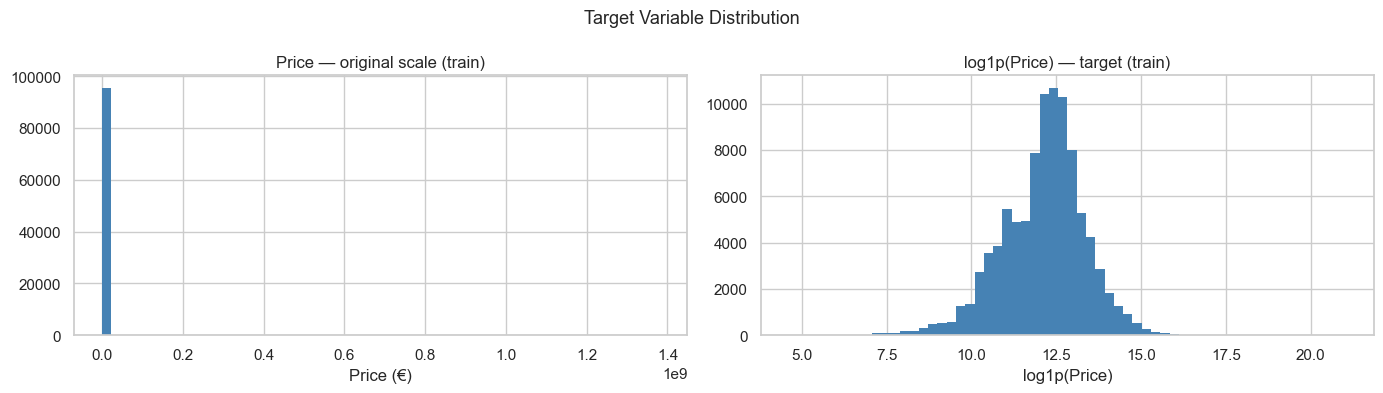

In [74]:
# Target Distribution - Price Log
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
axes[0].hist(np.expm1(y_train), bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('Price — original scale (train)')
axes[0].set_xlabel('Price (€)')
 
axes[1].hist(y_train, bins=60, color='steelblue', edgecolor='none')
axes[1].set_title('log1p(Price) — target (train)')
axes[1].set_xlabel('log1p(Price)')
 
plt.suptitle('Target Variable Distribution', fontsize=13)
plt.tight_layout()
plt.show()

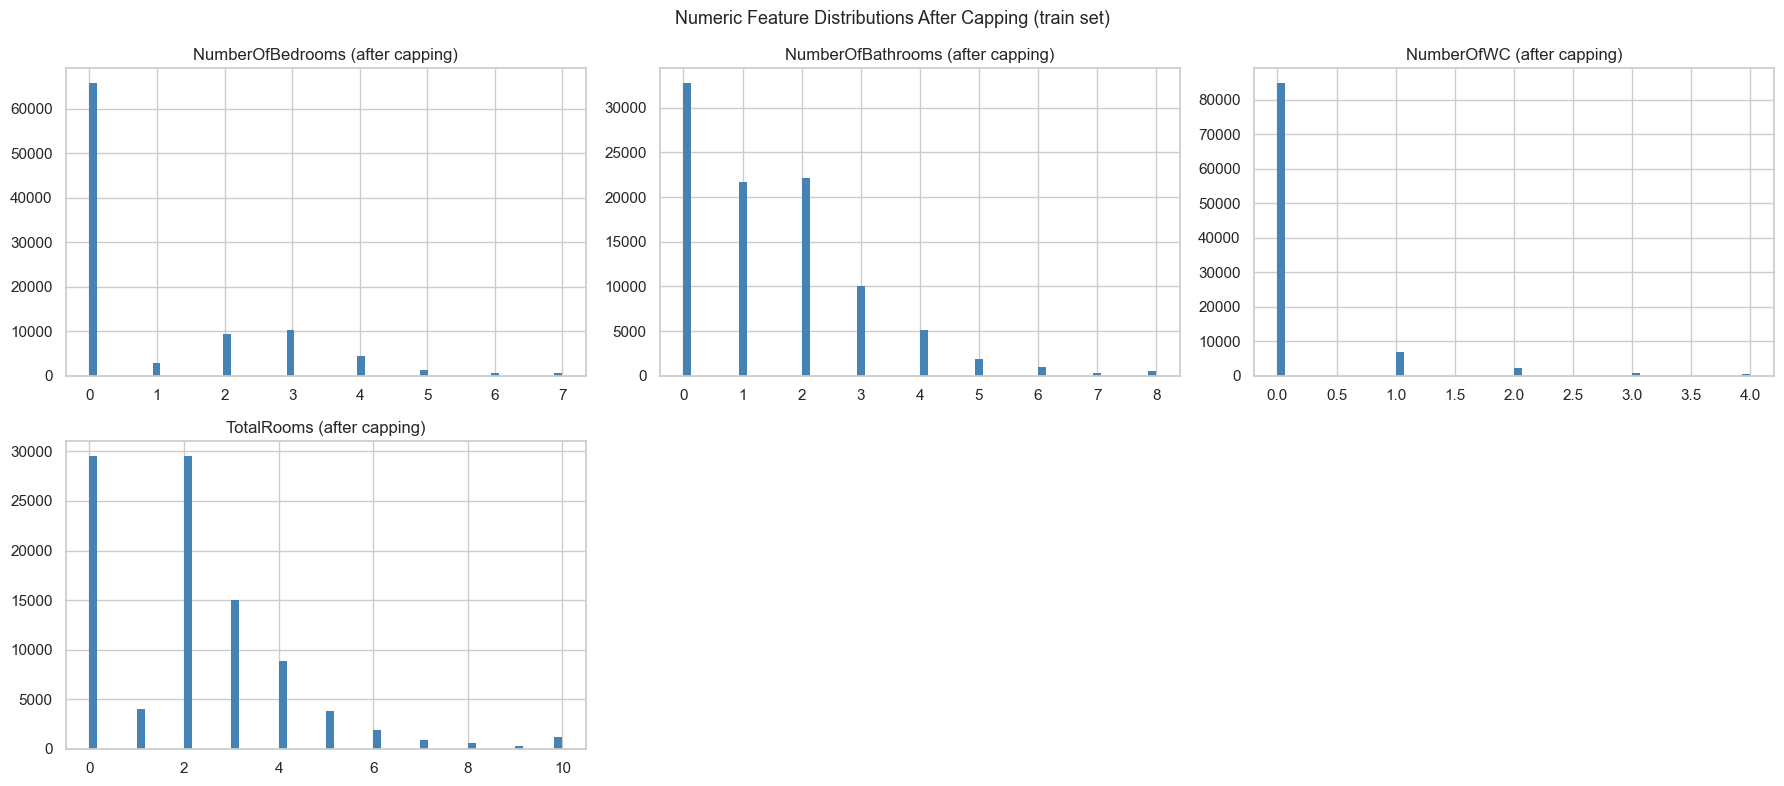

In [75]:
# Numeric distributions after capping 
num_plot_cols = [c for c in PERCENTILE_THRESHOLDS.keys() if c in X_train_capped.columns]
n_cols = 3
n_rows = -(-len(num_plot_cols) // n_cols)
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
 
for i, col in enumerate(num_plot_cols):
    axes[i].hist(X_train_capped[col].dropna(), bins=60, color='steelblue', edgecolor='none')
    axes[i].set_title(f'{col} (after capping)')
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle('Numeric Feature Distributions After Capping (train set)', fontsize=13)
plt.tight_layout()
plt.show()

In [76]:
# Missing values after pipeline
miss = X_train_capped.isnull().mean() * 100
miss = miss[miss > 0].sort_values(ascending=False)
 
if len(miss) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(miss) * 0.4)))
    miss.plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('% missing')
    ax.set_title('Remaining Missing Values After Cleaning (train set)')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values remaining after pipeline.")

No missing values remaining after pipeline.


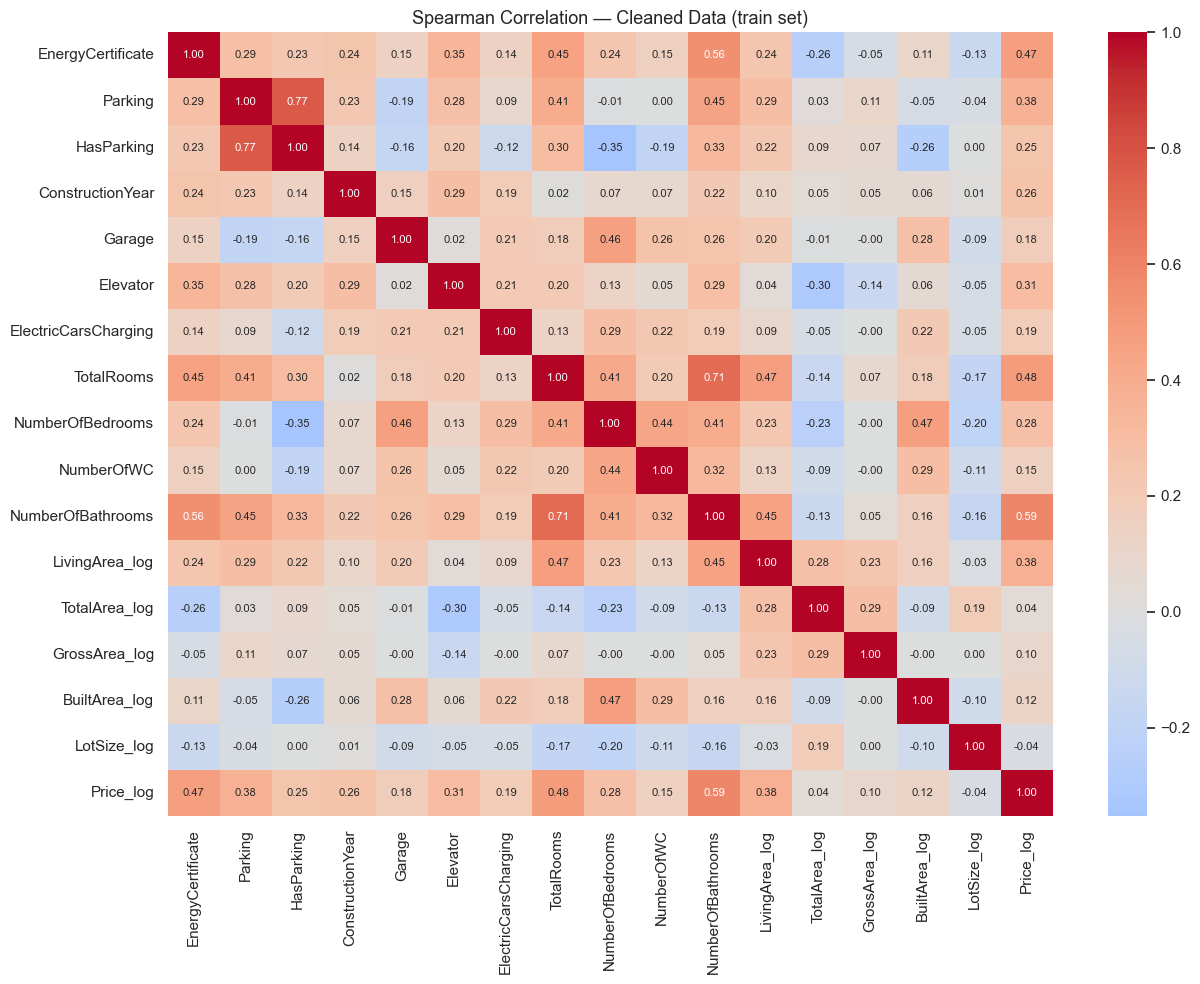

In [77]:
# Correlation heatmap (numeric, after capping + imputation)
num_for_corr = X_train_capped.select_dtypes(include=['number']).columns.tolist()
corr_data = pd.concat([X_train_capped[num_for_corr], y_train.rename('Price_log')], axis=1)
corr = corr_data.corr(method='spearman', numeric_only=True)
 
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Spearman Correlation — Cleaned Data (train set)', fontsize=13)
plt.tight_layout()
plt.show()

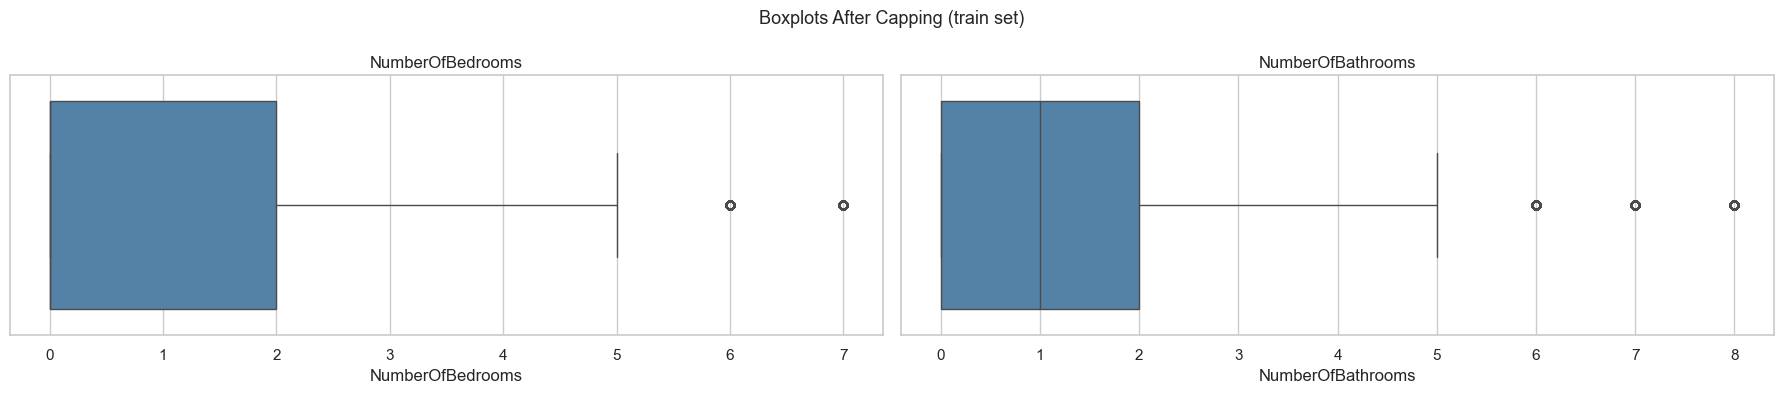

In [78]:
# Boxplots: key numeric features after capping 
box_cols = ['LivingArea', 'TotalArea', 'Price', 'NumberOfBedrooms', 'NumberOfBathrooms']
box_cols = [c for c in box_cols if c in X_train_capped.columns]
 
fig, axes = plt.subplots(1, len(box_cols), figsize=(18, 4))
for i, col in enumerate(box_cols):
    sns.boxplot(x=X_train_capped[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(col)
 
plt.suptitle('Boxplots After Capping (train set)', fontsize=13)
plt.tight_layout()
plt.show()

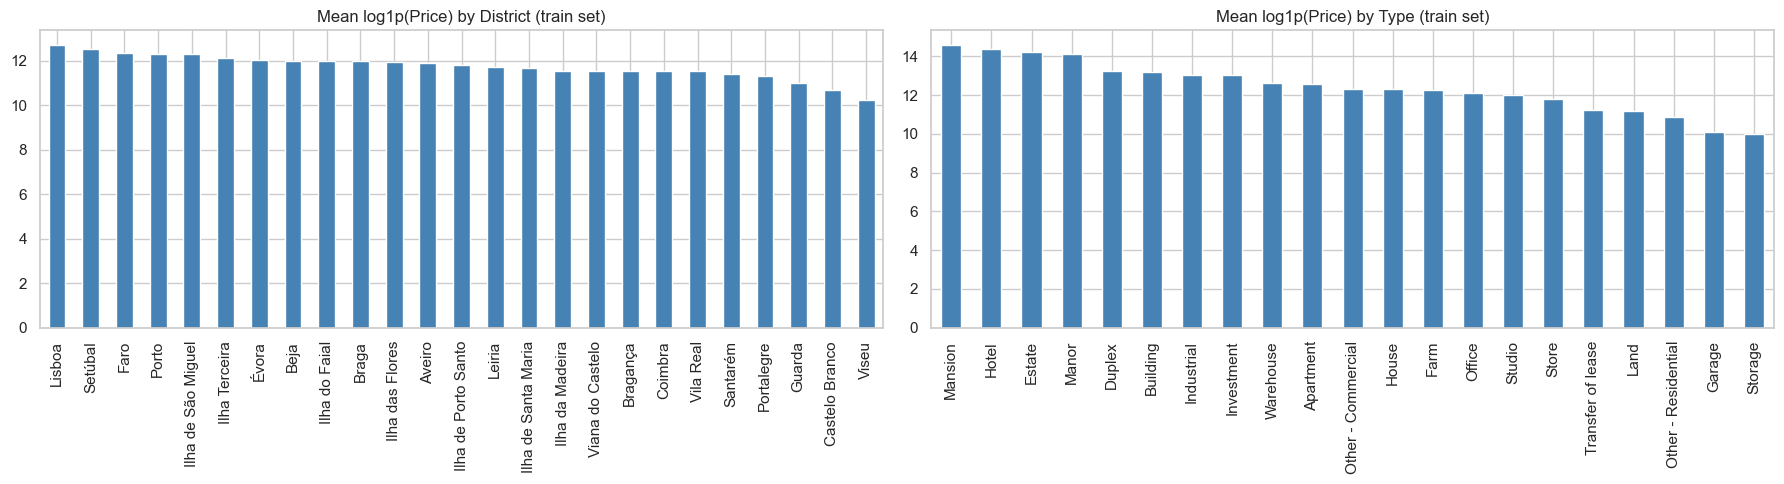

In [79]:
# Target encoding: mean price_log by District and Type
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
 
district_means = (
    pd.concat([X_train[['District']], y_train], axis=1)
    .groupby('District')['Price_log']
    .mean()
    .sort_values(ascending=False)
)
district_means.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Mean log1p(Price) by District (train set)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=90)
 
type_means = (
    pd.concat([X_train[['Type']], y_train], axis=1)
    .groupby('Type')['Price_log']
    .mean()
    .sort_values(ascending=False)
)
type_means.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('Mean log1p(Price) by Type (train set)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=90)
 
plt.tight_layout()
plt.show()